# ⚽ GMM Clustering dengan PCA — Raw Features La Liga

---

## 📋 Deskripsi Notebook

Notebook ini melakukan clustering gaya bermain klub La Liga menggunakan **Gaussian Mixture Model (GMM)** dengan pendekatan:

```
Raw Features (52 kolom)
    → StandardScaler
        → PCA (retain 95% variance)
            → GMM Clustering
                → Interpretation & Visualization
```

### Perbedaan dengan Notebook Sebelumnya

| Aspek | Notebook Style Scoring | Notebook Ini |
|-------|----------------------|--------------|
| **Input GMM** | 10 Style Scores (sudah di-engineer) | 52 Raw Features → PCA |
| **PCA** | Hanya untuk visualisasi | **Digunakan sebagai input model** |
| **Tujuan** | Clustering berdasarkan scoring buatan | GMM menemukan pola **secara alami** |

### Mengapa PCA Sebelum GMM?

1. **Reduksi dimensi** — 52 features untuk 20 klub berisiko *curse of dimensionality*. PCA mengompresi informasi ke dimensi yang lebih rendah.
2. **Menghilangkan multikolinearitas** — Banyak features yang saling berkorelasi tinggi (misal: `att_goals` vs `att_xg`). PCA menghasilkan komponen yang saling **ortogonal** (independen).
3. **Stabilitas estimasi** — GMM dengan `covariance_type='full'` membutuhkan estimasi banyak parameter. Dimensi lebih rendah membuat estimasi lebih stabil.
4. **Retain 95% informasi** — Dengan `PCA(n_components=0.95)`, kita mempertahankan 95% explained variance tanpa menentukan jumlah komponen secara manual.

---

## 1. Import Library

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from sqlalchemy import create_engine
from dotenv import load_dotenv

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
PCA_VARIANCE_THRESHOLD = 0.95  # Pertahankan 95% variance
K_RANGE = range(2, 7)          # Evaluasi k = 2..6

print("✅ Library berhasil diimpor.")

✅ Library berhasil diimpor.


---

## 2. Load Data

In [2]:
PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

DB_URL = (
    f"postgresql://{os.getenv('DB_USER', 'g')}:{os.getenv('DB_PASSWORD', '')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
    f"/{os.getenv('DB_NAME', 'laliga')}"
)

engine = create_engine(DB_URL)
df_gold = pd.read_sql("SELECT * FROM gold.teams_statistics ORDER BY club", engine)

print(f"✅ Data dimuat: {df_gold.shape[0]} klub × {df_gold.shape[1]} kolom")

✅ Data dimuat: 20 klub × 124 kolom


In [3]:
df_gold.head(3)

,club,played,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,att_np_goals,att_np_xg,att_np_goals_vs_xg,att_np_shots,att_np_sot,att_np_conv_pct,att_np_xg_per_shot,att_sp_goals,att_sp_shots,att_sp_xg,att_sp_goal_pct,att_sp_shot_pct,att_sp_xg_pct,att_touches_in_box,att_hit_woodwork,att_offsides,att_penalties_total,att_penalties_goals,att_free_kicks_total,att_free_kicks_goals,att_headers_total,att_headers_goals,att_fast_breaks_total,att_fast_breaks_goals,def_avg_possession_pct,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_ground_duels_won_pct,def_aerial_duels_won_pct,def_goals_conceded,def_xg_against,def_goals_vs_xg_against,def_shots_against,def_sot_against,def_conv_pct_against,def_xg_per_shot_against,def_shots_in_box_pct,def_goals_in_box_pct,def_sp_goals,def_sp_shots,def_sp_xg,def_sp_goal_pct,def_sp_shot_pct,def_sp_xg_pct,def_touches_in_box,def_hit_woodwork,def_offsides,def_penalties_total,def_penalties_goals,def_free_kicks_total,def_free_kicks_goals,def_headers_total,def_headers_goals,def_fast_breaks_total,def_fast_breaks_goals,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_total,pas_final_third_successful,pas_final_third_pct,pas_direction_fwd_pct,pas_direction_bwd_pct,pas_direction_left_pct,pas_direction_right_pct,pas_crosses_total,pas_crosses_successful,pas_crosses_pct,pas_through_balls,prs_pressed_seqs,prs_ppda,prs_start_distance,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_passes_10_plus,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_buildups_goals,seq_direct_attacks_total,seq_direct_attacks_goals,msc_subs_used,msc_subs_goals,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_fouled,msc_yellows,msc_reds,msc_pens_won,msc_fouls,msc_opp_yellows,msc_opp_reds,msc_pens_conceded,att_goals_per_game,att_shots_per_game,att_xg_per_game,att_fast_breaks_per_game,att_touches_in_box_per_game,def_tackles_per_game,def_interceptions_per_game,def_goals_conceded_per_game,pas_passes_per_game,pas_crosses_per_game,pas_through_balls_per_game,prs_pressed_seqs_per_game,seq_buildups_per_game,seq_direct_attacks_per_game,msc_fouls_per_game,msc_yellows_per_game
0,Alaves,38,44,47.05,-3.05,463,153,9.50,0.10,37,41.54,-4.54,456,146,8.11,0.09,11,135,11.00,25.00,29.16,23.37,778,12,74,7,7,10,1,82,6,29,1,48.00,691,297,1859,148,901,47.50,49.40,56,47.67,8.33,473,154,11.84,0.10,64.69,87.50,6,154,12.54,10.71,32.56,26.31,854,10,55,5,5,13,0,94,7,30,8,15362,12346,80.40,4305,2915,67.70,34.80,15.90,24.60,24.80,538,117,21.80,32,416,11.50,41.40,233,44,4,18.88,299,1.81,3.14,8.01,56,2,47,1,172,6,19,4,489,86,5,7,539,75,6,5,1.16,12.18,1.24,0.76,20.47,18.18,7.82,1.47,404.26,14.16,0.84,10.95,1.47,1.24,14.18,2.26
1,Athletic Bilbao,38,43,50.60,-7.60,522,172,8.24,0.10,38,45.87,-7.87,516,166,7.36,0.09,6,139,10.55,13.95,26.63,20.85,978,12,52,6,5,20,0,95,5,18,4,48.60,571,349,1983,78,808,45.50,49.60,58,42.24,15.76,357,161,16.25,0.12,64.43,79.31,9,88,5.53,15.52,24.65,13.08,610,4,127,6,3,7,2,50,5,38,7,15562,12496,80.30,5114,3421,66.90,35.00,14.60,25.50,25.00,698,137,19.60,59,557,11.20,45.00,368,61,3,16.58,276,2.03,3.08,8.12,57,2,42,5,189,8,27,6,391,73,7,6,497,75,4,6,1.13,13.74,1.33,0.47,25.74,15.03,9.18,1.53,409.53,18.37,1.55,14.66,1.50,1.11,13.08,1.92
2,Atlético Madrid,38,62,58.87,3.13,498,193,12.45,0.12,59,55.71,3.29,494,189,11.94,0.11,12,132,11.00,19.35,26.51,18.68,1060,15,79,4,3,10,2,105,12,33,8,53.30,647,297,1839,114,812,48.60,53.80,44,48.98,-4.98,441,142,9.98,0.11,61.45,81.82,9,133,11.22,20.45,30.16,22.90,752,9,59,6,5,15,0,82,7,27,7,19208,16443,85.60,5438,4121,75.80,30.20,15.70,27.10,27.00,561,130,23.20,100,427,12.20,42.30,267,31,5,11.61,495,1.70,4.16,11.03,124,6,64,2,184,18,22,4,345,77,5,4,399,75,2,6,1.63,13.11,1.55,0.87,27.89,17.03,7.82,1.16,505.47,14.76,2.63,11.24,3.26,1.68,10.50,2.03


---

## 3. Feature Selection — 52 Raw Features

In [4]:
FEATURES = {
    "Attacking Overall": [
        "att_goals", "att_xg", "att_goals_vs_xg",
        "att_shots", "att_sot", "att_conversion_pct", "att_xg_per_shot",
    ],
    "Attacking Non-Penalty": [
        "att_np_goals", "att_np_xg", "att_np_goals_vs_xg",
    ],
    "Attacking Set Pieces": [
        "att_sp_goals", "att_sp_xg", "att_sp_goal_pct", "att_sp_shot_pct",
    ],
    "Attacking Misc": [
        "att_touches_in_box", "att_fast_breaks_total", "att_fast_breaks_goals",
    ],
    "Defending Action": [
        "def_tackles", "def_interceptions", "def_possession_won",
        "def_blocks", "def_clearances", "def_avg_possession_pct",
    ],
    "Defending Overall": [
        "def_goals_conceded", "def_xg_against", "def_goals_vs_xg_against",
        "def_shots_against", "def_shots_in_box_pct",
    ],
    "Passing": [
        "pas_passes_total", "pas_passes_successful", "pas_passes_pct",
        "pas_final_third_pct", "pas_direction_fwd_pct", "pas_through_balls",
    ],
    "Pressing": [
        "prs_ppda", "prs_pressed_seqs", "prs_high_turnovers_total",
        "prs_high_turnovers_shot_ending", "prs_high_turnovers_goal_ending",
        "prs_high_turnovers_shot_pct",
    ],
    "Sequences": [
        "seq_direct_speed", "seq_passes_per_seq", "seq_sequence_time",
        "seq_buildups_total", "seq_direct_attacks_total", "seq_direct_attacks_goals",
    ],
    "Misc (Discipline)": [
        "msc_fouls", "msc_yellows", "msc_reds",
        "msc_errors_lead_to_shot", "msc_errors_lead_to_goal", "msc_pens_conceded",
    ],
}

feature_cols = []
for cols in FEATURES.values():
    feature_cols.extend(cols)

print("📊 Feature Selection")
print("=" * 50)
for cat, cols in FEATURES.items():
    print(f"   {cat:<25s}  →  {len(cols)} features")
print("=" * 50)
print(f"   TOTAL                      →  {len(feature_cols)} features")

# Validasi
missing = set(feature_cols) - set(df_gold.columns)
assert not missing, f"Feature tidak ditemukan: {missing}"
print(f"\n✅ Semua {len(feature_cols)} feature terverifikasi.")

📊 Feature Selection
   Attacking Overall          →  7 features
   Attacking Non-Penalty      →  3 features
   Attacking Set Pieces       →  4 features
   Attacking Misc             →  3 features
   Defending Action           →  6 features
   Defending Overall          →  5 features
   Passing                    →  6 features
   Pressing                   →  6 features
   Sequences                  →  6 features
   Misc (Discipline)          →  6 features
   TOTAL                      →  52 features

✅ Semua 52 feature terverifikasi.


---

## 4. Data Quality Check

### 4.1 Missing Value Check

In [5]:
df = df_gold[["club"] + feature_cols].copy()

# Konversi ke numerik (safety)
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

missing_total = df[feature_cols].isnull().sum().sum()
print(f"Missing values: {missing_total}")

if missing_total > 0:
    print(df[feature_cols].isnull().sum()[df[feature_cols].isnull().sum() > 0])
else:
    print("✅ Tidak ada missing values.")

Missing values: 0
✅ Tidak ada missing values.


### 4.2 Duplicate Check

In [6]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

if dup_count == 0:
    print("✅ Tidak ada duplikasi.")

Duplicate rows: 0
✅ Tidak ada duplikasi.


### 4.3 Correlation Check

Korelasi tinggi antar features menunjukkan **redundansi informasi**.  
Ini menjadi salah satu alasan penggunaan PCA — untuk mengeliminasi multikolinearitas.

In [7]:
corr = df[feature_cols].corr()

# Hitung pasangan dengan korelasi > 0.85
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr_pairs.append((
                corr.columns[i], corr.columns[j], corr.iloc[i, j]
            ))

print(f"📊 Pasangan fitur dengan |r| > 0.85: {len(high_corr_pairs)}")
print()
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:15]:
    print(f"   {f1:<35s}  ↔  {f2:<35s}  r = {r:+.3f}")

if len(high_corr_pairs) > 15:
    print(f"   ... dan {len(high_corr_pairs) - 15} pasangan lainnya.")

print(f"\n💡 Korelasi tinggi mengonfirmasi perlunya PCA untuk reduksi dimensi.")

📊 Pasangan fitur dengan |r| > 0.85: 57

   pas_passes_total                     ↔  pas_passes_successful                r = +0.999
   att_xg                               ↔  att_np_xg                            r = +0.990
   att_goals                            ↔  att_np_goals                         r = +0.989
   seq_passes_per_seq                   ↔  seq_sequence_time                    r = +0.989
   att_goals_vs_xg                      ↔  att_np_goals_vs_xg                   r = +0.985
   pas_passes_successful                ↔  seq_passes_per_seq                   r = +0.984
   pas_passes_total                     ↔  seq_passes_per_seq                   r = +0.979
   pas_passes_pct                       ↔  pas_direction_fwd_pct                r = -0.975
   pas_passes_successful                ↔  seq_sequence_time                    r = +0.974
   pas_passes_total                     ↔  seq_sequence_time                    r = +0.966
   pas_passes_total                     ↔  seq_bui

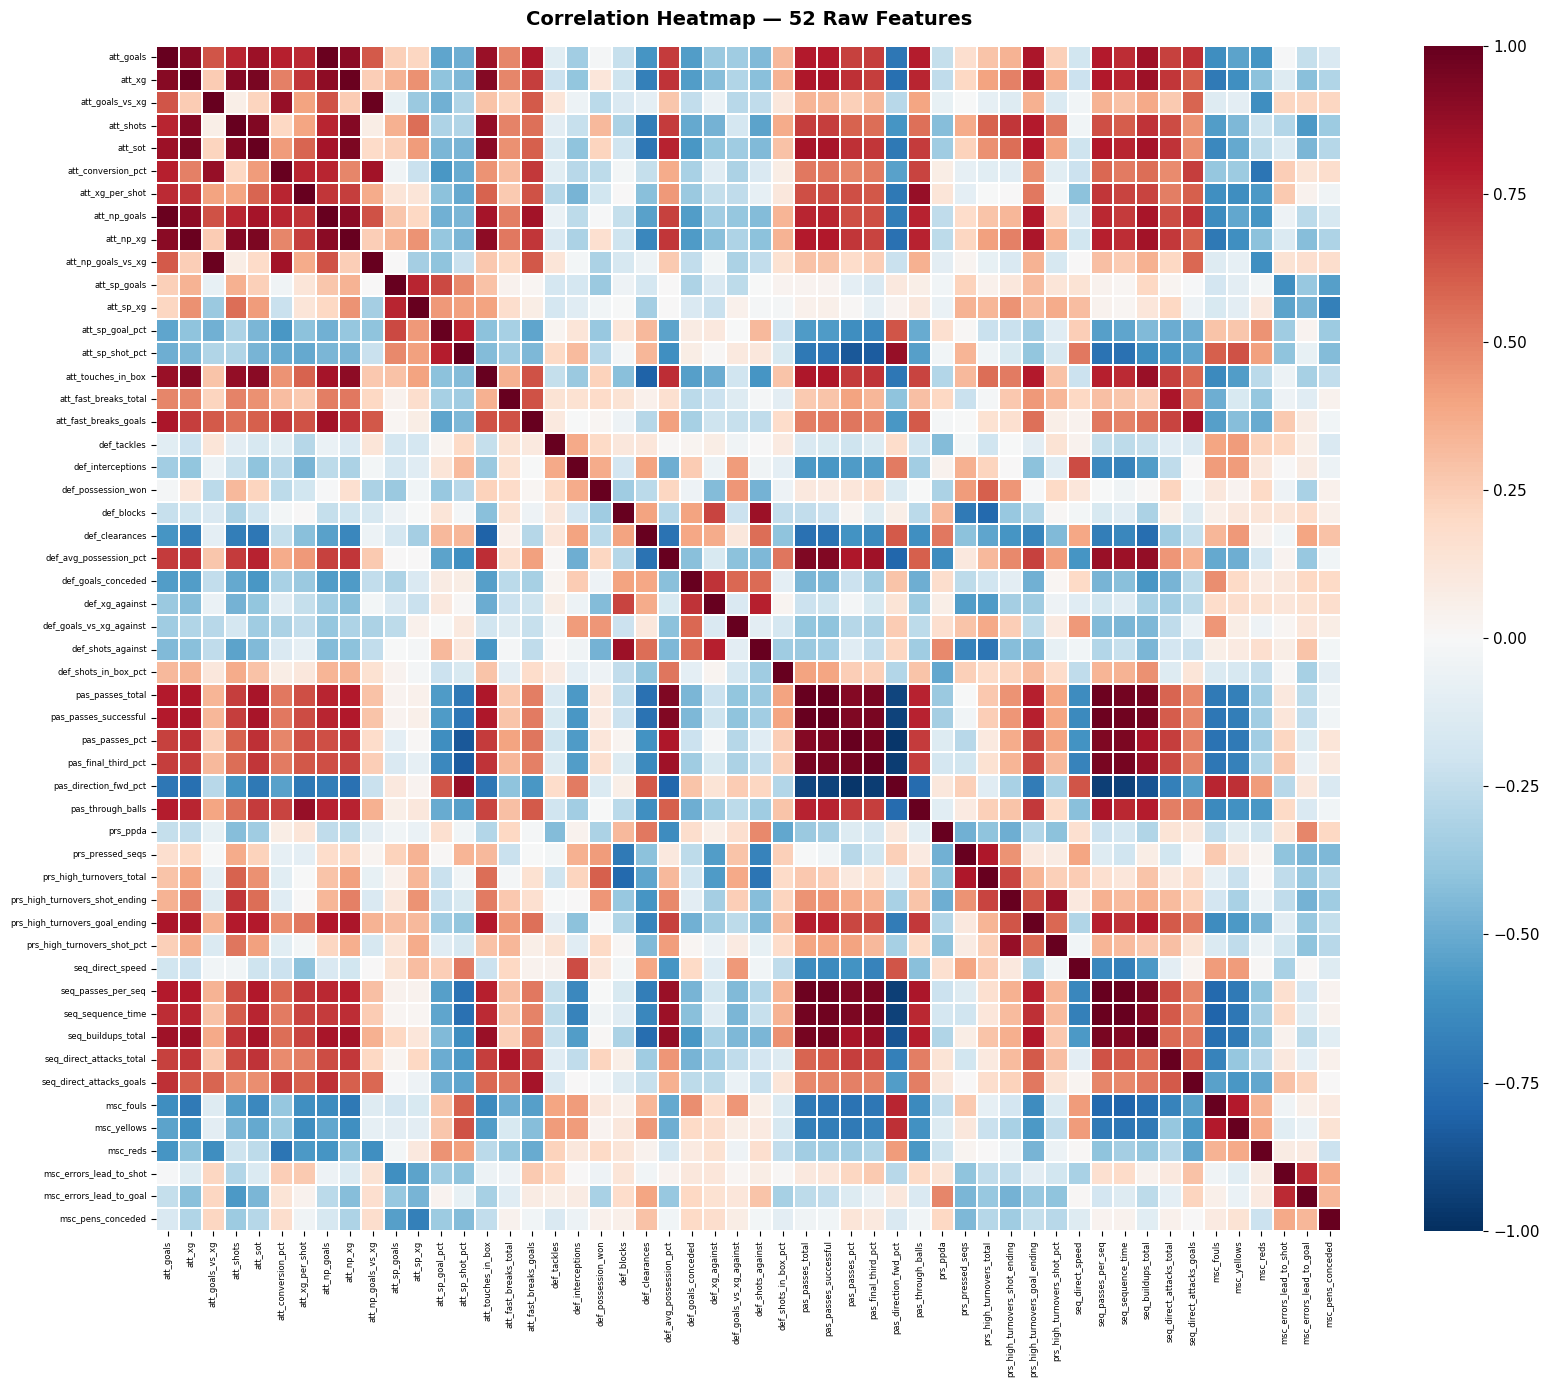

In [8]:
# --- Correlation Heatmap (full) ---
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.1, ax=ax, square=True,
)
ax.set_title("Correlation Heatmap — 52 Raw Features", fontsize=14, fontweight="bold", pad=15)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

---

## 5. StandardScaler

Seluruh feature memiliki satuan dan skala berbeda:  
- Goals → puluhan  
- Passes → ribuan  
- PPDA → rasio  
- Conversion % → persentase  

**StandardScaler** memastikan setiap feature berkontribusi proporsional:

$$X_{scaled} = \frac{X - \mu}{\sigma} \quad \Rightarrow \quad \text{mean} = 0, \quad \text{std} = 1$$

In [9]:
X_raw = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"✅ StandardScaler diterapkan.")
print(f"   Shape     : {X_scaled.shape}")
print(f"   Mean range: [{X_scaled.mean(axis=0).min():.6f}, {X_scaled.mean(axis=0).max():.6f}]  (≈ 0)")
print(f"   Std range : [{X_scaled.std(axis=0).min():.4f}, {X_scaled.std(axis=0).max():.4f}]  (≈ 1)")

✅ StandardScaler diterapkan.
   Shape     : (20, 52)
   Mean range: [-0.000000, 0.000000]  (≈ 0)
   Std range : [1.0000, 1.0000]  (≈ 1)


---

## 6. PCA — Principal Component Analysis

PCA mereduksi 52 features menjadi sejumlah **Principal Components (PC)** yang saling ortogonal.  
Dengan `n_components = 0.95`, PCA secara **otomatis** menentukan jumlah komponen yang mempertahankan **95% total explained variance**.

Keuntungan:
- Eliminasi multikolinearitas (komponen saling independen).
- Dimensi lebih rendah → GMM lebih stabil.
- Tidak perlu menentukan jumlah komponen secara manual.

In [10]:
pca = PCA(n_components=PCA_VARIANCE_THRESHOLD)
X_pca = pca.fit_transform(X_scaled)

n_components = pca.n_components_
total_variance = pca.explained_variance_ratio_.sum() * 100

print(f"📐 PCA Result")
print(f"   Input dimensions  : {X_scaled.shape[1]}")
print(f"   Output dimensions : {n_components}")
print(f"   Total explained   : {total_variance:.2f}%")
print(f"   Reduksi           : {X_scaled.shape[1]} → {n_components} ({(1 - n_components/X_scaled.shape[1])*100:.0f}% lebih ringan)")
print(f"\n   Explained Variance per Component:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    cum = pca.explained_variance_ratio_[:i+1].sum()
    bar = "█" * int(ev * 100)
    print(f"   PC{i+1:>2d}: {ev*100:5.2f}%  (cumulative: {cum*100:5.1f}%)  {bar}")

📐 PCA Result
   Input dimensions  : 52
   Output dimensions : 12
   Total explained   : 96.26%
   Reduksi           : 52 → 12 (77% lebih ringan)

   Explained Variance per Component:
   PC 1: 42.54%  (cumulative:  42.5%)  ██████████████████████████████████████████
   PC 2: 13.89%  (cumulative:  56.4%)  █████████████
   PC 3:  8.42%  (cumulative:  64.9%)  ████████
   PC 4:  7.74%  (cumulative:  72.6%)  ███████
   PC 5:  5.92%  (cumulative:  78.5%)  █████
   PC 6:  4.70%  (cumulative:  83.2%)  ████
   PC 7:  3.55%  (cumulative:  86.8%)  ███
   PC 8:  2.80%  (cumulative:  89.6%)  ██
   PC 9:  1.97%  (cumulative:  91.5%)  █
   PC10:  1.84%  (cumulative:  93.4%)  █
   PC11:  1.62%  (cumulative:  95.0%)  █
   PC12:  1.27%  (cumulative:  96.3%)  █


### 6.1 Visualisasi — Explained Variance per Component

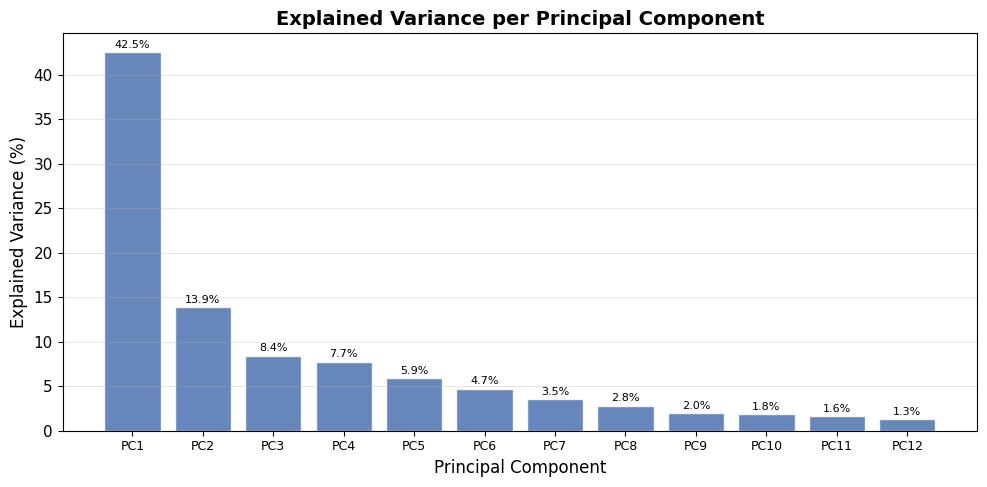

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

components = range(1, n_components + 1)
ax.bar(components, pca.explained_variance_ratio_ * 100,
       color='#4C72B0', edgecolor='white', alpha=0.85, label='Individual')

ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance (%)', fontsize=12)
ax.set_title('Explained Variance per Principal Component', fontsize=14, fontweight='bold')
ax.set_xticks(list(components))
ax.set_xticklabels([f'PC{i}' for i in components], fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

for i, ev in enumerate(pca.explained_variance_ratio_):
    ax.text(i + 1, ev * 100 + 0.5, f'{ev*100:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### 6.2 Visualisasi — Cumulative Explained Variance

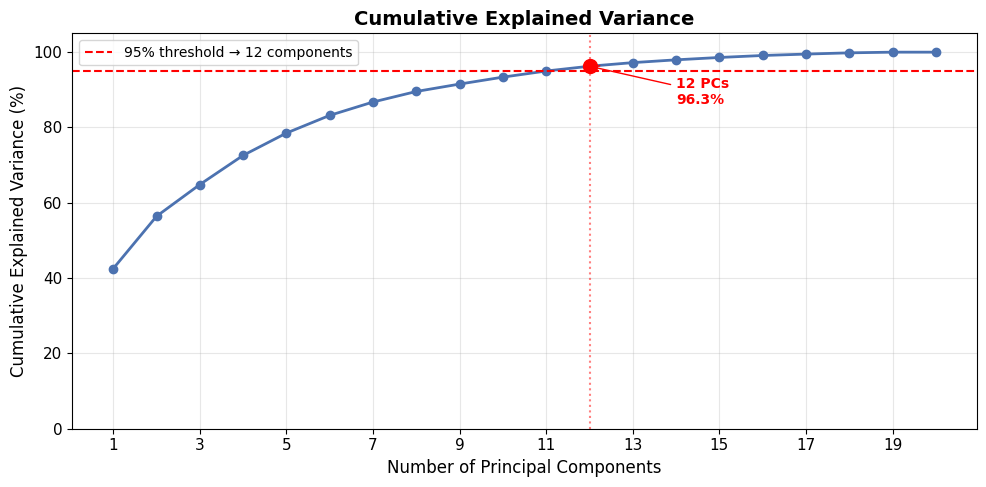

In [12]:
# Untuk grafik ini, hitung PCA lengkap (semua komponen)
pca_full = PCA().fit(X_scaled)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_variance) + 1), cum_variance,
        marker='o', linewidth=2, markersize=6, color='#4C72B0')

# Garis threshold 95%
ax.axhline(y=95, color='red', linestyle='--', linewidth=1.5,
           label=f'95% threshold → {n_components} components')

# Titik potong
ax.axvline(x=n_components, color='red', linestyle=':', alpha=0.5)
ax.scatter([n_components], [cum_variance[n_components - 1]],
           color='red', s=100, zorder=5)

ax.set_xlabel('Number of Principal Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, len(cum_variance) + 1, 2))
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax.annotate(
    f'{n_components} PCs\n{cum_variance[n_components-1]:.1f}%',
    xy=(n_components, cum_variance[n_components - 1]),
    xytext=(n_components + 2, cum_variance[n_components - 1] - 10),
    fontsize=10, fontweight='bold', color='red',
    arrowprops=dict(arrowstyle='->', color='red'),
)

plt.tight_layout()
plt.show()

### 6.3 Interpretasi PCA — Loading Matrix

Loading matrix menunjukkan **kontribusi setiap feature asli** terhadap setiap Principal Component.  
Feature dengan loading tinggi (positif atau negatif) pada suatu PC berarti feature tersebut **sangat berpengaruh** dalam membentuk komponen tersebut.

Interpretasi:
- **Loading positif tinggi** → Feature meningkat searah dengan nilai PC.
- **Loading negatif tinggi** → Feature bergerak berlawanan arah dengan nilai PC.
- **Loading mendekati 0** → Feature tidak relevan untuk PC tersebut.

In [13]:
# --- Loading Matrix ---
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=feature_cols,
)

print("📊 PCA Loading Matrix (top absolute loadings per PC):\n")
loadings.round(3)

📊 PCA Loading Matrix (top absolute loadings per PC):



,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
att_goals,0.20,0.00,0.13,0.10,-0.05,0.06,0.03,0.00,-0.05,-0.07,-0.03,0.02
att_xg,0.20,0.08,0.00,0.11,0.05,0.01,-0.01,0.01,-0.14,-0.01,0.04,0.09
att_goals_vs_xg,0.09,-0.14,0.31,0.02,-0.20,0.13,0.07,-0.02,0.15,-0.14,-0.15,-0.12
att_shots,0.17,0.19,-0.01,0.05,0.09,0.08,-0.04,-0.03,-0.07,0.06,-0.08,0.15
att_sot,0.19,0.10,-0.03,0.05,0.04,0.05,-0.09,-0.04,-0.14,-0.10,-0.09,0.04
att_conversion_pct,0.13,-0.17,0.23,0.08,-0.11,0.01,0.09,-0.04,-0.04,-0.24,0.05,-0.12
att_xg_per_shot,0.16,-0.12,0.04,0.12,-0.01,-0.15,0.07,0.12,-0.22,-0.20,0.32,0.00
att_np_goals,0.19,0.01,0.15,0.11,-0.06,0.09,0.02,-0.01,-0.07,0.02,-0.03,-0.03
att_np_xg,0.20,0.09,0.02,0.11,0.06,0.03,-0.03,0.01,-0.16,0.06,0.06,0.03
att_np_goals_vs_xg,0.08,-0.13,0.31,0.06,-0.23,0.14,0.09,-0.03,0.13,-0.05,-0.18,-0.11


In [14]:
# --- Top features per PC ---
N_TOP = 8  # Tampilkan 8 feature teratas per PC

print("🔍 Feature yang Paling Berkontribusi per Principal Component:\n")
for pc in loadings.columns:
    abs_sorted = loadings[pc].abs().sort_values(ascending=False)
    top_features = abs_sorted.head(N_TOP)

    print(f"   {pc} (explained: {pca.explained_variance_ratio_[int(pc[2:])-1]*100:.1f}%)")
    for feat in top_features.index:
        val = loadings.loc[feat, pc]
        direction = "+" if val > 0 else "−"
        print(f"      {direction} {feat:<40s}  loading = {val:+.3f}")
    print()

🔍 Feature yang Paling Berkontribusi per Principal Component:

   PC1 (explained: 42.5%)
      + seq_buildups_total                        loading = +0.203
      + pas_passes_successful                     loading = +0.202
      + pas_passes_total                          loading = +0.201
      + seq_passes_per_seq                        loading = +0.200
      + att_xg                                    loading = +0.197
      + att_goals                                 loading = +0.197
      + att_np_xg                                 loading = +0.195
      + seq_sequence_time                         loading = +0.193

   PC2 (explained: 13.9%)
      + prs_pressed_seqs                          loading = +0.304
      + prs_high_turnovers_total                  loading = +0.271
      + att_sp_xg                                 loading = +0.244
      − msc_errors_lead_to_goal                   loading = -0.237
      + prs_high_turnovers_shot_ending            loading = +0.232
      − msc_er

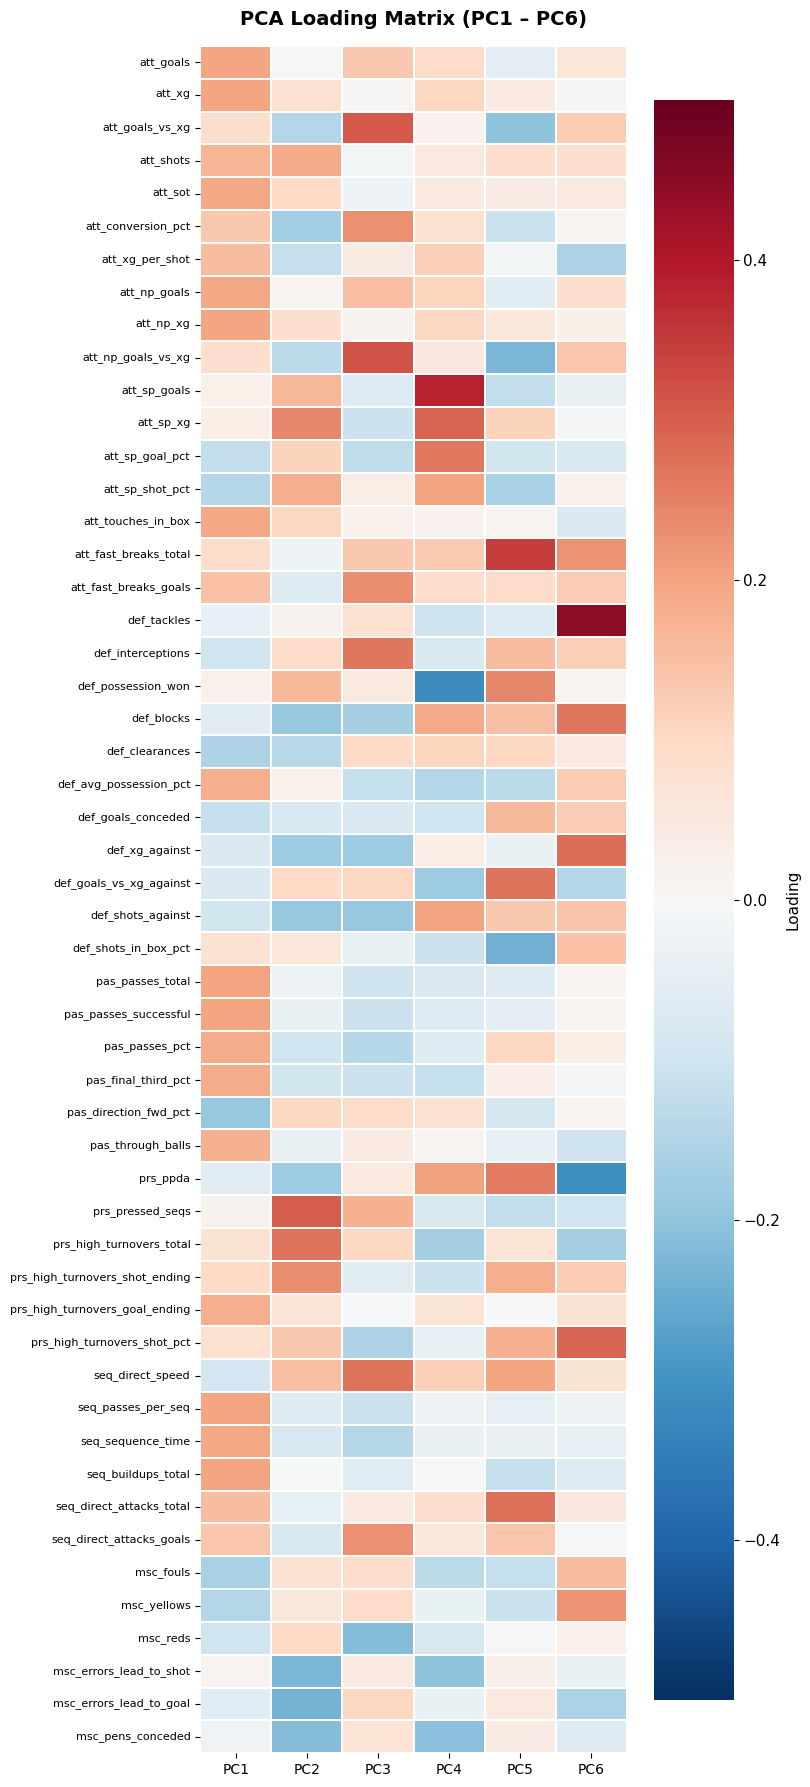

In [15]:
# --- Heatmap Loading Matrix ---
# Tampilkan hanya PCs yang paling penting (max 6 untuk readability)
n_show = min(n_components, 6)

fig, ax = plt.subplots(figsize=(8, 18))
sns.heatmap(
    loadings.iloc[:, :n_show],
    cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Loading'},
)
ax.set_title(f'PCA Loading Matrix (PC1 – PC{n_show})',
             fontsize=14, fontweight='bold', pad=15)
plt.yticks(fontsize=8)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

---

## 7. Gaussian Mixture Model — Menentukan Jumlah Cluster

### Mengapa BIC?

**BIC (Bayesian Information Criterion)** mengukur kualitas model dengan keseimbangan antara *goodness of fit* dan kompleksitas.  
BIC memiliki **penalti lebih besar** terhadap jumlah parameter dibanding AIC, sehingga mengurangi risiko overfitting — penting untuk dataset kecil (20 klub).

$$BIC = -2 \ln(L) + k \ln(n)$$

**Aturan:** Pilih k dengan **BIC terendah**.

In [16]:
bic_scores = []
aic_scores = []

for k in K_RANGE:
    gmm_eval = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=RANDOM_STATE,
        n_init=20,
        reg_covar=0.01,
    )
    gmm_eval.fit(X_pca)
    bic_scores.append(gmm_eval.bic(X_pca))
    aic_scores.append(gmm_eval.aic(X_pca))

best_k_bic = list(K_RANGE)[np.argmin(bic_scores)]
best_k_aic = list(K_RANGE)[np.argmin(aic_scores)]

print(f"{'k':>4s}  {'BIC':>10s}  {'AIC':>10s}")
print("-" * 30)
for k, bic, aic in zip(K_RANGE, bic_scores, aic_scores):
    bic_m = " ◀" if k == best_k_bic else ""
    aic_m = " ◀" if k == best_k_aic else ""
    print(f"   {k}  {bic:>10.1f}{bic_m}  {aic:>10.1f}{aic_m}")

print(f"\n   BIC minimum → k = {best_k_bic}")
print(f"   AIC minimum → k = {best_k_aic}")

   k         BIC         AIC
------------------------------
   2      1085.7       905.5
   3       971.9 ◀       701.1 ◀
   4      1165.8       804.4
   5      1292.6       840.5
   6      1462.1       919.4

   BIC minimum → k = 3
   AIC minimum → k = 3


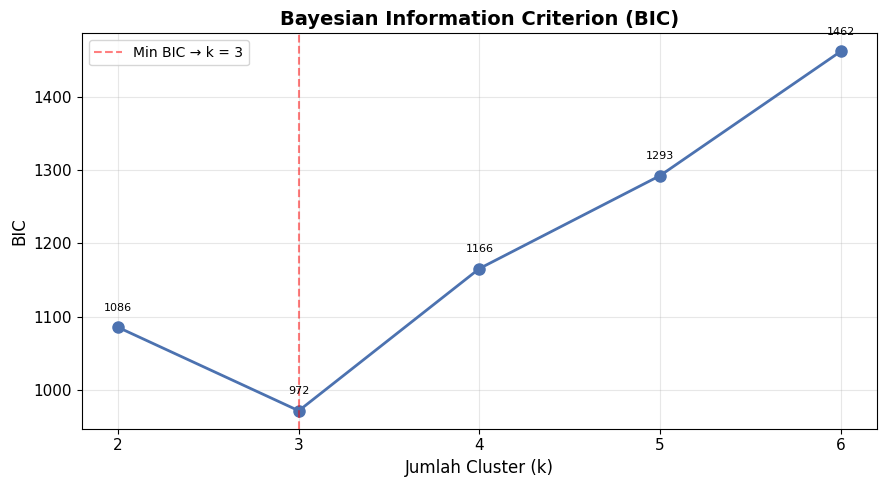

In [17]:
# --- Grafik BIC ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_RANGE, bic_scores, marker='o', linewidth=2, markersize=8, color='#4C72B0')
ax.axvline(best_k_bic, color='red', linestyle='--', alpha=0.5,
           label=f'Min BIC → k = {best_k_bic}')
ax.set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax.set_ylabel('BIC', fontsize=12)
ax.set_title('Bayesian Information Criterion (BIC)', fontsize=14, fontweight='bold')
ax.set_xticks(list(K_RANGE))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

for k, bic in zip(K_RANGE, bic_scores):
    ax.annotate(f"{bic:.0f}", (k, bic), textcoords="offset points",
                xytext=(0, 12), fontsize=8, ha='center')
plt.tight_layout()
plt.show()

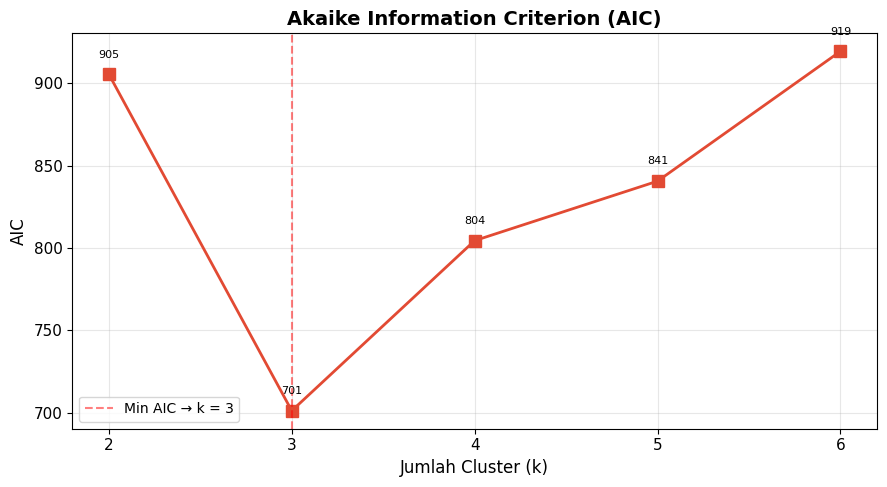

In [18]:
# --- Grafik AIC ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_RANGE, aic_scores, marker='s', linewidth=2, markersize=8, color='#E24A33')
ax.axvline(best_k_aic, color='red', linestyle='--', alpha=0.5,
           label=f'Min AIC → k = {best_k_aic}')
ax.set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax.set_ylabel('AIC', fontsize=12)
ax.set_title('Akaike Information Criterion (AIC)', fontsize=14, fontweight='bold')
ax.set_xticks(list(K_RANGE))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

for k, aic in zip(K_RANGE, aic_scores):
    ax.annotate(f"{aic:.0f}", (k, aic), textcoords="offset points",
                xytext=(0, 12), fontsize=8, ha='center')
plt.tight_layout()
plt.show()

In [19]:
OPTIMAL_K = best_k_bic
print(f"✅ Jumlah cluster dipilih berdasarkan BIC: k = {OPTIMAL_K}")

✅ Jumlah cluster dipilih berdasarkan BIC: k = 3


---

## 8. Training Model Final

In [20]:
gmm = GaussianMixture(
    n_components=OPTIMAL_K,
    covariance_type='full',
    random_state=RANDOM_STATE,
    n_init=20,
    reg_covar=0.01,
)

cluster_labels = gmm.fit_predict(X_pca)
df["cluster"] = cluster_labels

print(f"✅ GMM training selesai.")
print(f"   Converged  : {gmm.converged_}")
print(f"   Iterations : {gmm.n_iter_}")
print(f"   BIC        : {gmm.bic(X_pca):.2f}")
print(f"   AIC        : {gmm.aic(X_pca):.2f}")
print(f"\n   Distribusi cluster:")
for cid, cnt in df["cluster"].value_counts().sort_index().items():
    clubs = df[df["cluster"] == cid]["club"].tolist()
    print(f"   Cluster {cid} ({cnt} klub): {', '.join(clubs)}")

✅ GMM training selesai.
   Converged  : True
   Iterations : 2
   BIC        : 971.92
   AIC        : 701.08

   Distribusi cluster:
   Cluster 0 (8 klub): Alaves, Athletic Bilbao, Elche, Girona, Rayo Vallecano, Real Sociedad, Sevilla, Valencia
   Cluster 1 (6 klub): Atlético Madrid, Barcelona, Celta Vigo, Real Betis, Real Madrid, Villarreal
   Cluster 2 (6 klub): Espanyol, Getafe, Levante, Mallorca, Osasuna, Real Oviedo


---

## 9. Membership Probability

**Membership probability** adalah probabilitas posterior bahwa sebuah sampel berasal dari sebuah komponen Gaussian.  
Ini merupakan keunggulan utama GMM sebagai **soft clustering**:
- Setiap klub mendapatkan probabilitas pada **setiap** cluster.
- Jumlah probabilitas per klub = 1.0.
- Klub dengan probabilitas tersebar = karakter bermain campuran/hibrida.

In [21]:
proba = gmm.predict_proba(X_pca)

proba_cols = [f"prob_cluster_{i}" for i in range(OPTIMAL_K)]
for i, col in enumerate(proba_cols):
    df[col] = proba[:, i]

df["max_probability"] = proba.max(axis=1)

# Tampilkan
display_cols = ["club", "cluster"] + proba_cols + ["max_probability"]
df_proba = df[display_cols].sort_values(
    ["cluster", "max_probability"], ascending=[True, False]
).reset_index(drop=True)

df_proba.round(4)

,club,cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2,max_probability
0,Alaves,0,1.00,0.00,0.00,1.00
1,Athletic Bilbao,0,1.00,0.00,0.00,1.00
2,Elche,0,1.00,0.00,0.00,1.00
3,Girona,0,1.00,0.00,0.00,1.00
4,Rayo Vallecano,0,1.00,0.00,0.00,1.00
5,Real Sociedad,0,1.00,0.00,0.00,1.00
6,Sevilla,0,1.00,0.00,0.00,1.00
7,Valencia,0,1.00,0.00,0.00,1.00
8,Atlético Madrid,1,0.00,1.00,0.00,1.00
9,Barcelona,1,0.00,1.00,0.00,1.00


---

## 10. Visualisasi

### 10.1 Probability Heatmap

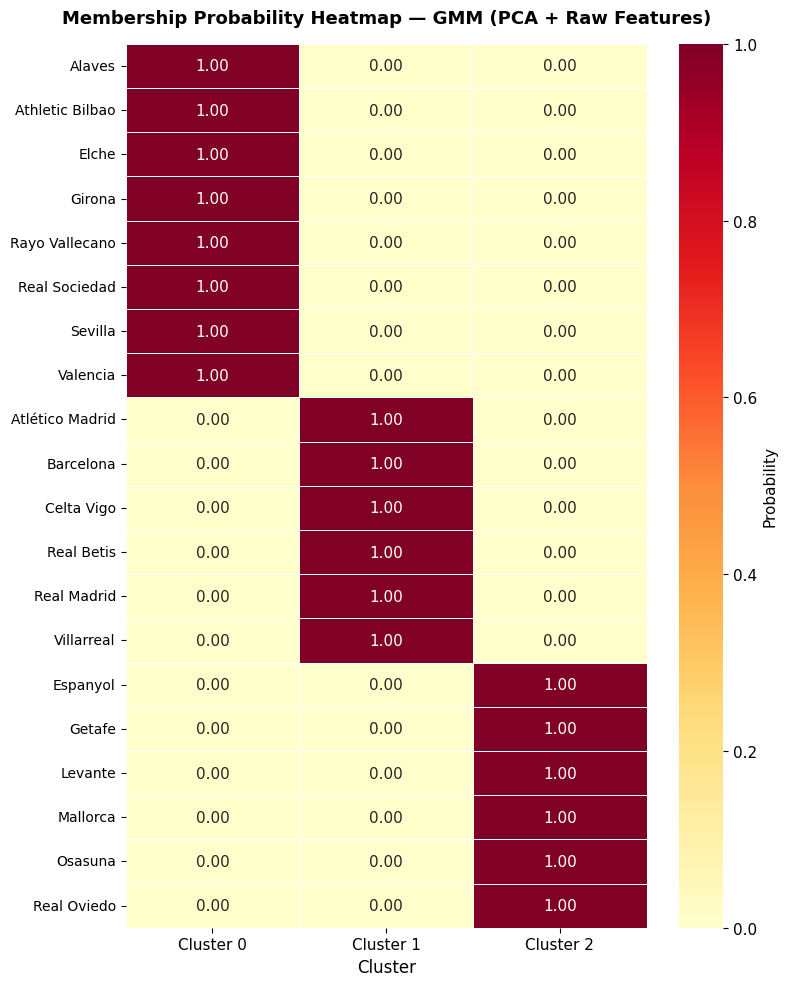

In [22]:
df_hmap = df.set_index("club")[proba_cols].copy()
df_hmap.columns = [f"Cluster {i}" for i in range(OPTIMAL_K)]
order = df.sort_values(["cluster", "max_probability"], ascending=[True, False])["club"]
df_hmap = df_hmap.loc[order]

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    df_hmap, annot=True, fmt=".2f",
    cmap="YlOrRd", vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Probability"},
)
ax.set_title("Membership Probability Heatmap — GMM (PCA + Raw Features)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 10.2 PCA Scatter Plot (PC1 vs PC2)

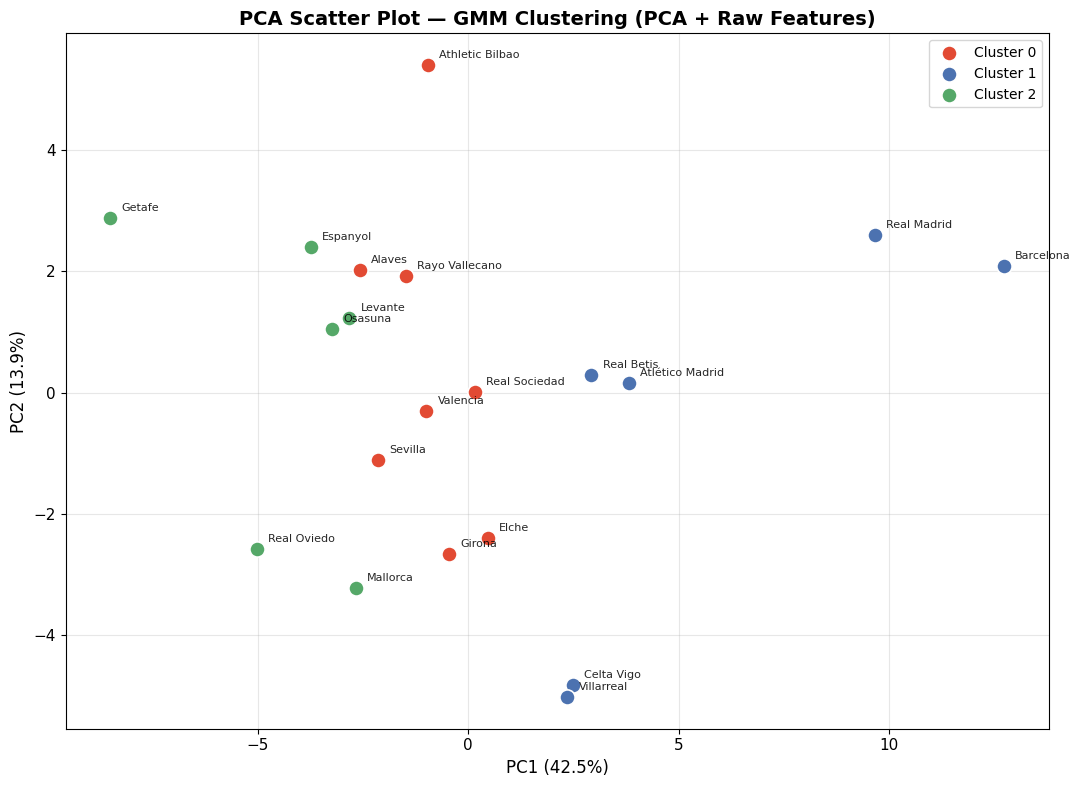

In [23]:
cluster_colors = ['#E24A33', '#4C72B0', '#55A868', '#8172B2', '#C44E52',
                  '#CCB974', '#64B5CD', '#8C8C8C', '#FF9F1C', '#2EC4B6']

ev1 = pca.explained_variance_ratio_[0] * 100
ev2 = pca.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(11, 8))

for cid in sorted(df["cluster"].unique()):
    mask = df["cluster"] == cid
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cid], s=120,
        label=f"Cluster {cid}",
        edgecolors='white', linewidth=1.2, zorder=3,
    )

for i, club in enumerate(df["club"]):
    ax.annotate(club, (X_pca[i, 0], X_pca[i, 1]),
                textcoords="offset points", xytext=(8, 5),
                fontsize=8, alpha=0.85)

ax.set_xlabel(f"PC1 ({ev1:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({ev2:.1f}%)", fontsize=12)
ax.set_title("PCA Scatter Plot — GMM Clustering (PCA + Raw Features)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10.3 Probability Distribution

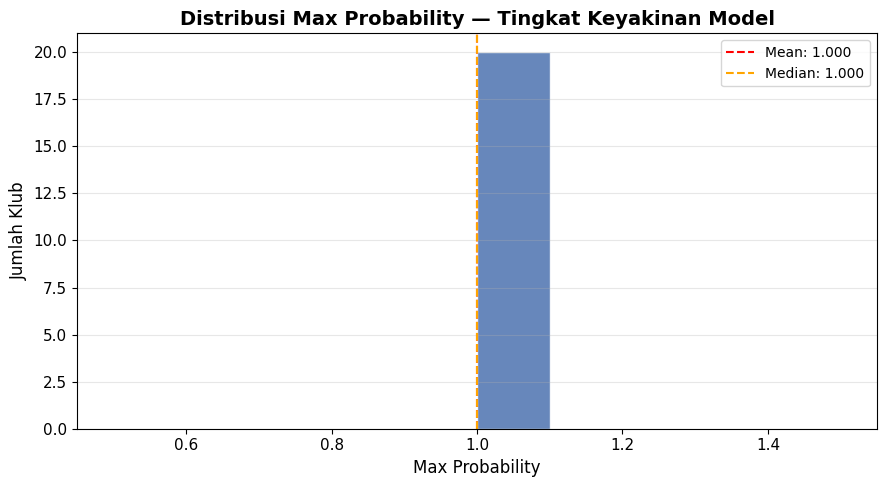

   Min    : 1.0000
   Max    : 1.0000
   Mean   : 1.0000
   Median : 1.0000


In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["max_probability"], bins=10, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(df["max_probability"].mean(), color="red", linestyle="--",
           label=f"Mean: {df['max_probability'].mean():.3f}")
ax.axvline(df["max_probability"].median(), color="orange", linestyle="--",
           label=f"Median: {df['max_probability'].median():.3f}")
ax.set_xlabel("Max Probability", fontsize=12)
ax.set_ylabel("Jumlah Klub", fontsize=12)
ax.set_title("Distribusi Max Probability — Tingkat Keyakinan Model",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"   Min    : {df['max_probability'].min():.4f}")
print(f"   Max    : {df['max_probability'].max():.4f}")
print(f"   Mean   : {df['max_probability'].mean():.4f}")
print(f"   Median : {df['max_probability'].median():.4f}")

### 10.4 Cluster Size

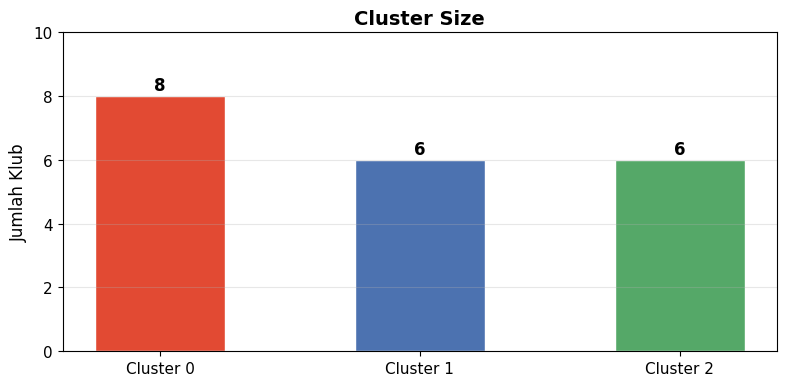

In [25]:
cluster_counts = df["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [f"Cluster {i}" for i in cluster_counts.index],
    cluster_counts.values,
    color=[cluster_colors[i] for i in cluster_counts.index],
    edgecolor='white', width=0.5,
)
for bar, cnt in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(cnt), ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel("Jumlah Klub", fontsize=12)
ax.set_title("Cluster Size", fontsize=14, fontweight="bold")
ax.set_ylim(0, cluster_counts.max() + 2)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

## 11. Cluster Profile — Rata-rata Feature per Cluster

Menghitung rata-rata seluruh 52 features untuk setiap cluster, kemudian mengidentifikasi feature yang paling membedakan setiap cluster dari rata-rata liga (z-score).

In [26]:
cluster_mean = df.groupby("cluster")[feature_cols].mean()
cluster_std = df.groupby("cluster")[feature_cols].std()

global_mean = df[feature_cols].mean()
global_std = df[feature_cols].std()

# Z-score per cluster
cluster_zscore = (cluster_mean - global_mean) / global_std

print("📊 Cluster Profile (mean values):")
cluster_mean.round(2)

📊 Cluster Profile (mean values):


,att_goals,att_xg,att_goals_vs_xg,att_shots,att_sot,att_conversion_pct,att_xg_per_shot,att_np_goals,att_np_xg,att_np_goals_vs_xg,att_sp_goals,att_sp_xg,att_sp_goal_pct,att_sp_shot_pct,att_touches_in_box,att_fast_breaks_total,att_fast_breaks_goals,def_tackles,def_interceptions,def_possession_won,def_blocks,def_clearances,def_avg_possession_pct,def_goals_conceded,def_xg_against,def_goals_vs_xg_against,def_shots_against,def_shots_in_box_pct,pas_passes_total,pas_passes_successful,pas_passes_pct,pas_final_third_pct,pas_direction_fwd_pct,pas_through_balls,prs_ppda,prs_pressed_seqs,prs_high_turnovers_total,prs_high_turnovers_shot_ending,prs_high_turnovers_goal_ending,prs_high_turnovers_shot_pct,seq_direct_speed,seq_passes_per_seq,seq_sequence_time,seq_buildups_total,seq_direct_attacks_total,seq_direct_attacks_goals,msc_fouls,msc_yellows,msc_reds,msc_errors_lead_to_shot,msc_errors_lead_to_goal,msc_pens_conceded
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,45.88,48.06,-2.19,463.25,155.75,9.99,0.10,40.38,42.64,-2.27,7.62,9.28,16.69,27.15,818.12,30.88,4.50,647.38,310.00,1835.12,131.38,925.00,51.04,55.75,52.61,3.14,468.75,65.87,16416.25,13573.75,82.54,70.21,33.54,50.38,11.42,418.38,257.50,43.50,3.12,16.92,1.83,3.41,9.30,62.38,50.88,3.62,484.62,84.12,5.88,27.00,6.00,7.00
1,69.67,64.61,5.05,538.83,202.00,13.06,0.12,63.00,58.57,4.43,10.50,10.13,15.03,23.50,1047.83,45.00,8.67,618.83,296.00,1785.33,123.17,862.33,54.45,42.83,46.37,-3.54,438.17,64.91,19775.33,17196.00,86.60,76.62,29.27,97.83,12.50,402.00,256.83,43.50,6.83,16.63,1.78,4.32,11.67,131.83,76.33,6.83,388.00,70.67,3.33,27.67,6.50,6.83
2,39.83,42.93,-3.10,424.50,139.67,9.33,0.10,36.50,38.59,-2.09,12.50,11.07,32.28,33.54,721.17,27.50,3.33,613.67,309.83,1720.00,143.17,1022.50,44.17,53.50,55.12,-1.62,517.83,63.36,13710.33,10802.83,78.37,62.97,37.48,34.83,12.95,397.50,234.83,34.17,2.33,14.60,1.92,2.97,8.06,39.00,42.67,2.67,473.67,85.83,6.67,22.50,7.17,6.17


In [27]:
# --- Top 10 & Bottom 10 features per cluster ---
print("🔍 Feature yang Paling Membedakan Setiap Cluster")
print("   (Z-score: selisih dari rata-rata liga dalam satuan std)")
print("=" * 80)

for cid in sorted(cluster_zscore.index):
    clubs = df[df["cluster"] == cid]["club"].tolist()
    zs = cluster_zscore.loc[cid].sort_values(ascending=False)

    print(f"\n── Cluster {cid} ({len(clubs)} klub: {', '.join(clubs)}) ──")

    print(f"\n   🟢 Top 10 TERTINGGI:")
    for rank, (feat, z) in enumerate(zs.head(10).items(), 1):
        print(f"      {rank:2d}. {feat:<40s}  z = {z:+.2f}  (mean = {cluster_mean.loc[cid, feat]:.2f})")

    print(f"\n   🔴 Top 10 TERENDAH:")
    for rank, (feat, z) in enumerate(zs.tail(10).items(), 1):
        print(f"      {rank:2d}. {feat:<40s}  z = {z:+.2f}  (mean = {cluster_mean.loc[cid, feat]:.2f})")

print("\n" + "=" * 80)

🔍 Feature yang Paling Membedakan Setiap Cluster
   (Z-score: selisih dari rata-rata liga dalam satuan std)

── Cluster 0 (8 klub: Alaves, Athletic Bilbao, Elche, Girona, Rayo Vallecano, Real Sociedad, Sevilla, Valencia) ──

   🟢 Top 10 TERTINGGI:
       1. def_possession_won                        z = +0.64  (mean = 1835.12)
       2. def_goals_vs_xg_against                   z = +0.58  (mean = 3.14)
       3. msc_fouls                                 z = +0.54  (mean = 484.62)
       4. def_goals_conceded                        z = +0.54  (mean = 55.75)
       5. def_tackles                               z = +0.37  (mean = 647.38)
       6. msc_yellows                               z = +0.30  (mean = 84.12)
       7. def_shots_in_box_pct                      z = +0.26  (mean = 65.87)
       8. prs_high_turnovers_shot_ending            z = +0.24  (mean = 43.50)
       9. prs_high_turnovers_shot_pct               z = +0.23  (mean = 16.92)
      10. msc_reds                              

---

## 12. Radar Chart — Perbandingan Cluster

Untuk radar chart, dipilih **12 features representatif** yang mencakup seluruh aspek permainan.  
Nilai dinormalisasi ke 0–1 menggunakan Min-Max agar bisa dibandingkan antar feature.

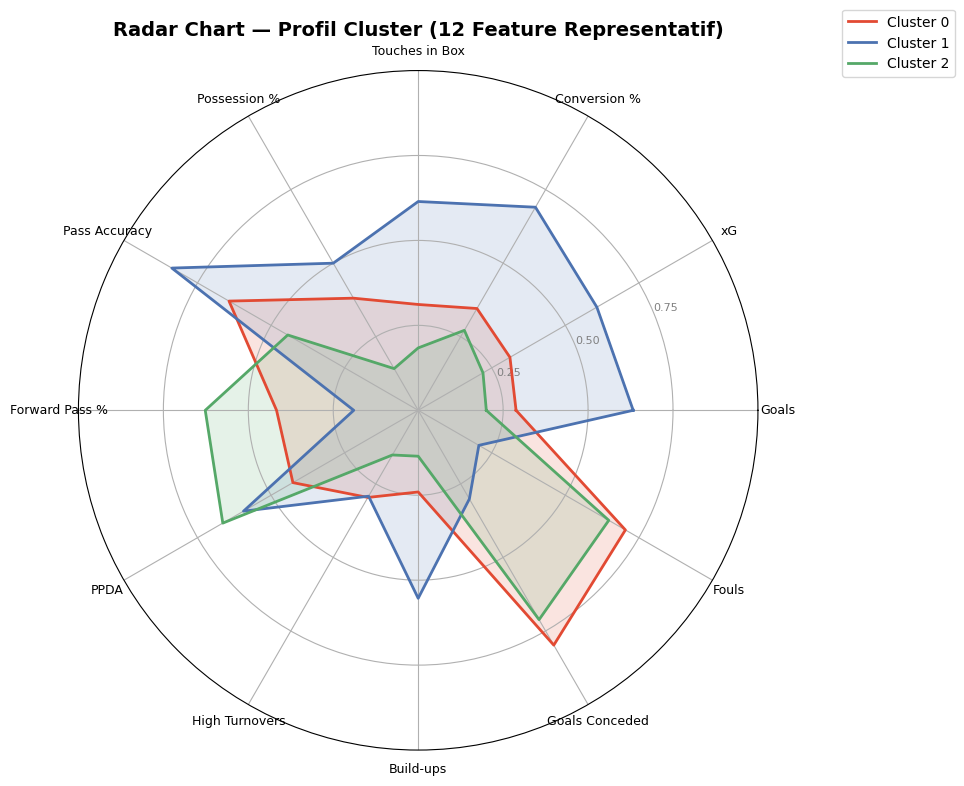

In [28]:
# --- 12 feature representatif untuk radar ---
RADAR_FEATURES = [
    "att_goals",              # Attacking
    "att_xg",                 # Attacking quality
    "att_conversion_pct",     # Efficiency
    "att_touches_in_box",     # Attacking presence
    "def_avg_possession_pct", # Possession
    "pas_passes_pct",         # Passing accuracy
    "pas_direction_fwd_pct",  # Direct play
    "prs_ppda",               # Pressing (inverse: lower = more pressing)
    "prs_high_turnovers_total", # High pressing result
    "seq_buildups_total",     # Build-up play
    "def_goals_conceded",     # Defensive
    "msc_fouls",              # Discipline
]

# Normalisasi 0-1 per feature (untuk radar chart)
radar_mean = cluster_mean[RADAR_FEATURES].copy()
for col in RADAR_FEATURES:
    mn = df[col].min()
    mx = df[col].max()
    if mx != mn:
        radar_mean[col] = (radar_mean[col] - mn) / (mx - mn)
    else:
        radar_mean[col] = 0.5

# Labels pendek
radar_labels = [
    "Goals", "xG", "Conversion %", "Touches in Box",
    "Possession %", "Pass Accuracy", "Forward Pass %",
    "PPDA", "High Turnovers", "Build-ups",
    "Goals Conceded", "Fouls",
]

num_vars = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for cid in sorted(radar_mean.index):
    values = radar_mean.loc[cid].tolist()
    values += values[:1]
    ax.fill(angles, values, alpha=0.15, color=cluster_colors[cid])
    ax.plot(angles, values, linewidth=2, color=cluster_colors[cid],
            label=f"Cluster {cid}")

ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75])
ax.set_yticklabels(["0.25", "0.50", "0.75"], fontsize=8, color="gray")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_title("Radar Chart — Profil Cluster (12 Feature Representatif)",
             fontsize=14, fontweight="bold", pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

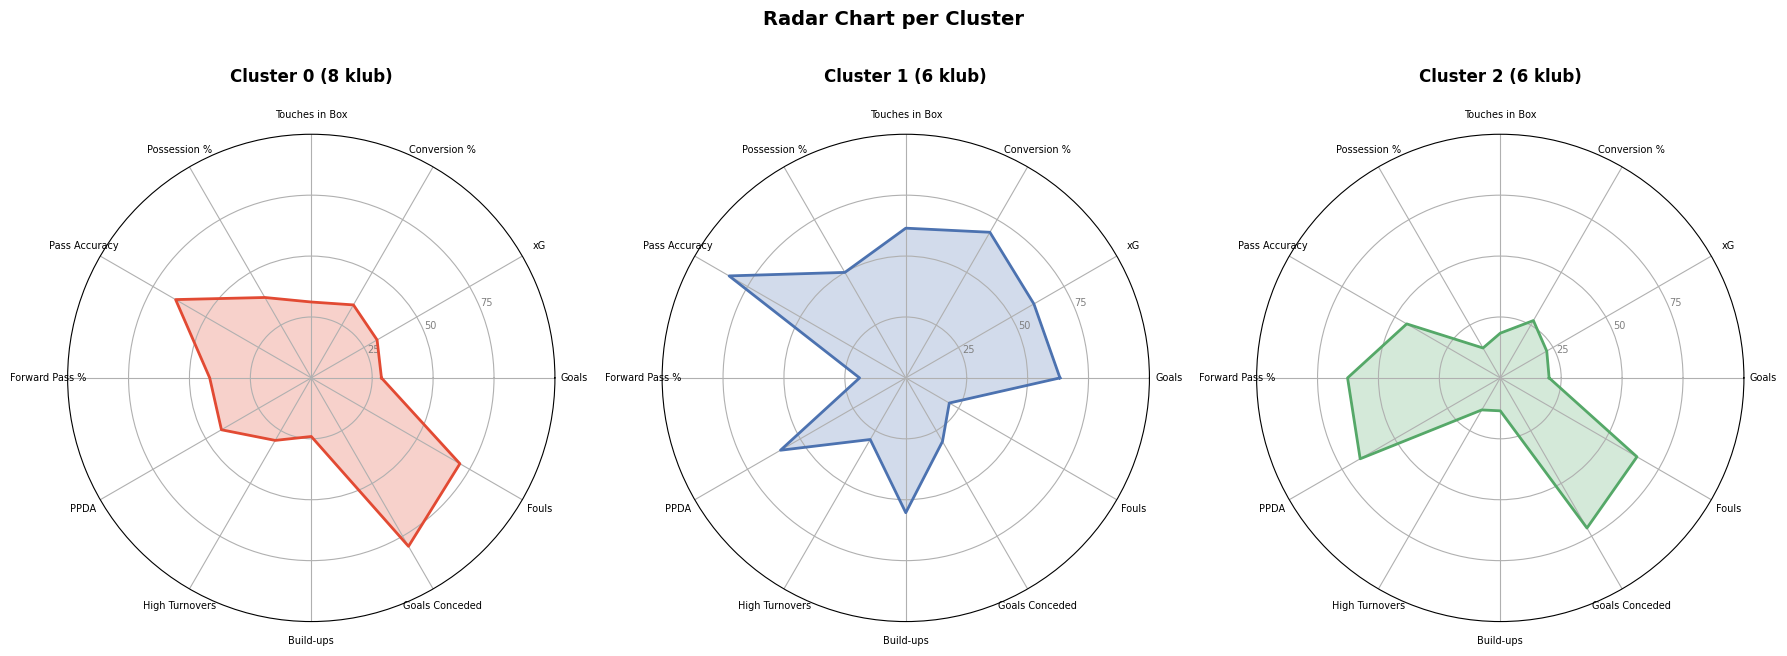

In [29]:
# --- Radar terpisah per cluster ---
n_clusters = len(radar_mean)
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 6),
                         subplot_kw=dict(polar=True))
if n_clusters == 1:
    axes = [axes]

for cid, ax in zip(sorted(radar_mean.index), axes):
    values = radar_mean.loc[cid].tolist() + [radar_mean.loc[cid].iloc[0]]
    clubs = df[df["cluster"] == cid]["club"].tolist()

    ax.fill(angles, values, alpha=0.25, color=cluster_colors[cid])
    ax.plot(angles, values, linewidth=2, color=cluster_colors[cid])
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75])
    ax.set_yticklabels(["25", "50", "75"], fontsize=7, color="gray")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=7)
    ax.set_title(f"Cluster {cid} ({len(clubs)} klub)",
                 fontsize=12, fontweight="bold", pad=20)

plt.suptitle("Radar Chart per Cluster", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

---

## 13. Analisis Soft Clustering

Karena GMM menghasilkan probabilitas, kita menganalisis:
1. **Cluster utama** dan **cluster kedua** setiap klub.
2. **Tingkat keyakinan** — apakah klub memiliki identitas kuat atau karakter campuran.

Klasifikasi:
- **> 0.95** → Identitas gaya bermain **sangat jelas**.
- **0.60 – 0.95** → Karakter bermain **campuran** (menunjukkan fleksibilitas taktis).
- **< 0.60** → Probabilitas tinggi pada **lebih dari satu cluster** (hibrida kuat).

In [30]:
# --- Analisis cluster utama & kedua ---
analysis_rows = []

for idx, row in df.iterrows():
    club = row["club"]
    probs = np.array([row[c] for c in proba_cols])
    sorted_idx = np.argsort(-probs)  # Descending

    primary_cluster = sorted_idx[0]
    primary_prob = probs[sorted_idx[0]]
    secondary_cluster = sorted_idx[1]
    secondary_prob = probs[sorted_idx[1]]

    analysis_rows.append({
        "club": club,
        "primary_cluster": primary_cluster,
        "primary_prob": primary_prob,
        "secondary_cluster": secondary_cluster,
        "secondary_prob": secondary_prob,
    })

df_analysis = pd.DataFrame(analysis_rows).sort_values(
    ["primary_cluster", "primary_prob"], ascending=[True, False]
).reset_index(drop=True)

print("📊 Primary & Secondary Cluster per Klub:\n")
df_analysis.round(4)

📊 Primary & Secondary Cluster per Klub:



,club,primary_cluster,primary_prob,secondary_cluster,secondary_prob
0,Alaves,0,1.00,1,0.00
1,Athletic Bilbao,0,1.00,1,0.00
2,Elche,0,1.00,1,0.00
3,Girona,0,1.00,1,0.00
4,Rayo Vallecano,0,1.00,1,0.00
5,Real Sociedad,0,1.00,1,0.00
6,Sevilla,0,1.00,1,0.00
7,Valencia,0,1.00,1,0.00
8,Atlético Madrid,1,1.00,0,0.00
9,Barcelona,1,1.00,0,0.00


In [31]:
# --- Kategorisasi ---
print("🔍 Kategorisasi Berdasarkan Probabilitas:\n")

# Identitas sangat jelas (> 0.95)
very_clear = df_analysis[df_analysis["primary_prob"] > 0.95]
print(f"🎯 Identitas SANGAT JELAS (prob > 95%): {len(very_clear)} klub")
for _, r in very_clear.iterrows():
    print(f"   • {r['club']:<20s} → Cluster {int(r['primary_cluster'])} ({r['primary_prob']:.1%})")

# Karakter campuran (0.60 - 0.95)
mixed = df_analysis[
    (df_analysis["primary_prob"] >= 0.60) &
    (df_analysis["primary_prob"] <= 0.95)
]
print(f"\n🔀 Karakter CAMPURAN (prob 60-95%): {len(mixed)} klub")
for _, r in mixed.iterrows():
    print(f"   • {r['club']:<20s} → C{int(r['primary_cluster'])} ({r['primary_prob']:.1%}), "
          f"C{int(r['secondary_cluster'])} ({r['secondary_prob']:.1%})")

# Hibrida kuat (< 0.60)
hybrid = df_analysis[df_analysis["primary_prob"] < 0.60]
print(f"\n⚠️ HIBRIDA KUAT (prob < 60%): {len(hybrid)} klub")
for _, r in hybrid.iterrows():
    print(f"   • {r['club']:<20s} → C{int(r['primary_cluster'])} ({r['primary_prob']:.1%}), "
          f"C{int(r['secondary_cluster'])} ({r['secondary_prob']:.1%})")

🔍 Kategorisasi Berdasarkan Probabilitas:

🎯 Identitas SANGAT JELAS (prob > 95%): 20 klub
   • Alaves               → Cluster 0 (100.0%)
   • Athletic Bilbao      → Cluster 0 (100.0%)
   • Elche                → Cluster 0 (100.0%)
   • Girona               → Cluster 0 (100.0%)
   • Rayo Vallecano       → Cluster 0 (100.0%)
   • Real Sociedad        → Cluster 0 (100.0%)
   • Sevilla              → Cluster 0 (100.0%)
   • Valencia             → Cluster 0 (100.0%)
   • Atlético Madrid      → Cluster 1 (100.0%)
   • Barcelona            → Cluster 1 (100.0%)
   • Celta Vigo           → Cluster 1 (100.0%)
   • Real Betis           → Cluster 1 (100.0%)
   • Real Madrid          → Cluster 1 (100.0%)
   • Villarreal           → Cluster 1 (100.0%)
   • Espanyol             → Cluster 2 (100.0%)
   • Getafe               → Cluster 2 (100.0%)
   • Levante              → Cluster 2 (100.0%)
   • Mallorca             → Cluster 2 (100.0%)
   • Osasuna              → Cluster 2 (100.0%)
   • Real Oviedo  

---

## 14. Analisis per Klub

In [32]:
print("📋 Analisis Klub — GMM (PCA + Raw Features)")
print("=" * 90)

for cid in sorted(df["cluster"].unique()):
    cdata = df[df["cluster"] == cid].sort_values("max_probability", ascending=False)

    # Ciri cluster dari z-score
    top_feats = cluster_zscore.loc[cid].nlargest(3)
    traits = ", ".join([f.replace("_", " ") for f in top_feats.index])

    print(f"\n── Cluster {cid} (Ciri: {traits}) ──\n")

    for _, row in cdata.iterrows():
        club = row["club"]
        max_p = row["max_probability"]

        probs = [(i, row[c]) for i, c in enumerate(proba_cols)]
        probs_sorted = sorted(probs, key=lambda x: x[1], reverse=True)
        probs_str = ", ".join([f"C{p[0]}: {p[1]:.0%}" for p in probs_sorted if p[1] > 0.01])

        if max_p >= 0.95:
            status = "🎯 Identitas sangat jelas"
        elif max_p >= 0.80:
            status = "✅ Identitas kuat"
        elif max_p >= 0.60:
            status = "🔀 Karakter campuran"
        else:
            status = "⚠️ Hibrida kuat"

        print(f"   • {club:<20s} │ {status}")
        print(f"     Probabilitas    : {probs_str}")
        print()

print("=" * 90)

📋 Analisis Klub — GMM (PCA + Raw Features)

── Cluster 0 (Ciri: def possession won, def goals vs xg against, msc fouls) ──

   • Alaves               │ 🎯 Identitas sangat jelas
     Probabilitas    : C0: 100%

   • Athletic Bilbao      │ 🎯 Identitas sangat jelas
     Probabilitas    : C0: 100%

   • Elche                │ 🎯 Identitas sangat jelas
     Probabilitas    : C0: 100%

   • Girona               │ 🎯 Identitas sangat jelas
     Probabilitas    : C0: 100%

   • Rayo Vallecano       │ 🎯 Identitas sangat jelas
     Probabilitas    : C0: 100%

   • Real Sociedad        │ 🎯 Identitas sangat jelas
     Probabilitas    : C0: 100%

   • Sevilla              │ 🎯 Identitas sangat jelas
     Probabilitas    : C0: 100%

   • Valencia             │ 🎯 Identitas sangat jelas
     Probabilitas    : C0: 100%


── Cluster 1 (Ciri: pas through balls, att np goals, att goals) ──

   • Atlético Madrid      │ 🎯 Identitas sangat jelas
     Probabilitas    : C1: 100%

   • Barcelona            │ 🎯 Ide

---

## 15. Simpan Hasil

In [33]:
output_dir = PROJECT_ROOT / "data" / "ml_ready"
output_dir.mkdir(parents=True, exist_ok=True)

export_cols = ["club", "cluster"] + proba_cols + ["max_probability"]
df_export = df[export_cols].sort_values("club").reset_index(drop=True)

output_path = output_dir / "gmm_clusters_raw_features.csv"
df_export.to_csv(output_path, index=False)

print(f"✅ Hasil disimpan: {output_path.name}")
print(f"   Shape: {df_export.shape}")
print()
df_export

✅ Hasil disimpan: gmm_clusters_raw_features.csv
   Shape: (20, 6)



,club,cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2,max_probability
0,Alaves,0,1.00,0.00,0.00,1.00
1,Athletic Bilbao,0,1.00,0.00,0.00,1.00
2,Atlético Madrid,1,0.00,1.00,0.00,1.00
3,Barcelona,1,0.00,1.00,0.00,1.00
4,Celta Vigo,1,0.00,1.00,0.00,1.00
5,Elche,0,1.00,0.00,0.00,1.00
6,Espanyol,2,0.00,0.00,1.00,1.00
7,Getafe,2,0.00,0.00,1.00,1.00
8,Girona,0,1.00,0.00,0.00,1.00
9,Levante,2,0.00,0.00,1.00,1.00


---

## 16. Kesimpulan

### Pipeline

```
52 Raw Features → StandardScaler → PCA (95% variance) → GMM → Cluster + Probability
```

### Hasil PCA
- 52 features direduksi menjadi **beberapa Principal Components** yang mempertahankan **95% variance**.
- Loading matrix menunjukkan fitur mana yang paling berkontribusi pada setiap komponen.
- Reduksi dimensi membuat estimasi GMM lebih **stabil** dan menghilangkan multikolinearitas.

### Hasil GMM
- Jumlah cluster optimal dipilih berdasarkan **BIC terendah**.
- Setiap klub mendapat **membership probability** pada setiap cluster.
- Beberapa klub menunjukkan **karakter bermain hibrida** — probabilitas tersebar di beberapa cluster.

### GMM Raw Features vs Style Scoring

| Aspek | Style Scoring → GMM | Raw Features → PCA → GMM |
|-------|--------------------|--------------------------|
| **Input** | 10 scores (sudah di-engineer) | 52 raw features (via PCA) |
| **Bias** | Dipengaruhi bobot style scoring | Model menemukan pola **alami** |
| **Interpretasi** | Mudah (langsung dari nama score) | Perlu analisis loading PCA |
| **Dimensi** | 10 dimensi (rendah) | Tergantung PCA (medium) |
| **Validitas** | Bergantung kualitas scoring | Langsung dari data statistik |

Kedua pendekatan saling **melengkapi**:
- **Style scoring** memberikan interpretasi yang mudah dan intuitif.
- **Raw features + PCA** memvalidasi apakah pola yang ditemukan konsisten tanpa bias pembobotan.
- Jika kedua pendekatan menghasilkan cluster yang **mirip**, ini memperkuat validitas hasil.

### Output
- `data/ml_ready/gmm_clusters_raw_features.csv`